Saving data.xlsx to data (21).xlsx
===== 원본 데이터 =====


,연도,기업 시가총액(억 원),M2 통화량(조 원)
0,2020,1000,3000
1,2021,1200,3300
2,2022,1500,3800
3,2023,1700,4200
4,2024,2100,4500
5,2025,2400,5100


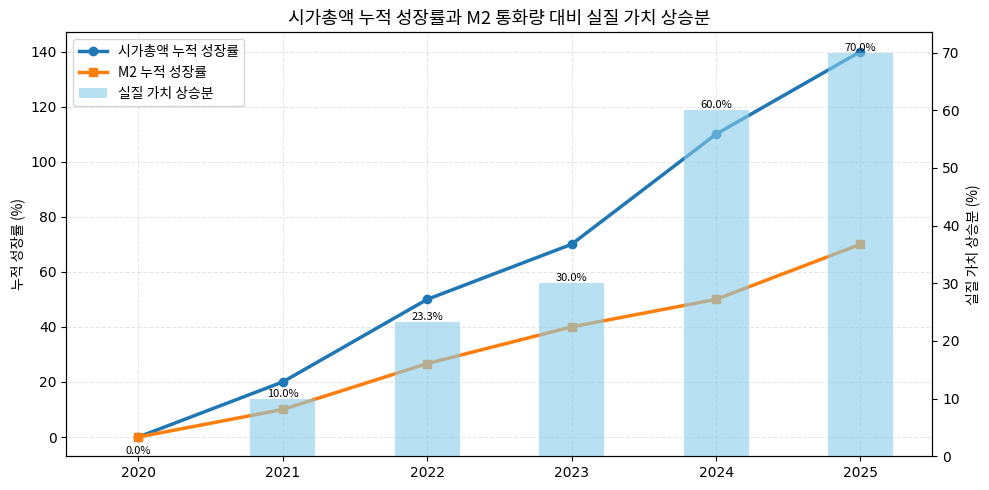

,연도,시가총액 누적 성장률 (%),M2 누적 성장률 (%),실질 가치 상승분 (%)
0,2020,0.0,0.0,0.0
1,2021,20.0,10.0,10.0
2,2022,50.0,26.7,23.3
3,2023,70.0,40.0,30.0
4,2024,110.0,50.0,60.0
5,2025,140.0,70.0,70.0


In [27]:
# ============================================================
# 시가총액 누적 성장률 vs M2 누적 성장률 분석
# Google Colab 전용
# ============================================================

# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ------------------------------------------------------------
# 한글 폰트 설치
# ------------------------------------------------------------
import os
os.system("apt-get -qq install fonts-noto-cjk > /dev/null 2>&1")

# ------------------------------------------------------------
# 라이브러리
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from google.colab import files
from IPython.display import display
import io

# ------------------------------------------------------------
# 한글 폰트 객체 생성
# ------------------------------------------------------------
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
fontprop = fm.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 엑셀 업로드
# ------------------------------------------------------------
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(
    io.BytesIO(uploaded[file_name])
)

# ------------------------------------------------------------
# 데이터 확인
# ------------------------------------------------------------
print("===== 원본 데이터 =====")
display(df)

# ------------------------------------------------------------
# 컬럼 자동 인식
# ------------------------------------------------------------
year_col = df.columns[0]
marketcap_col = df.columns[1]
m2_col = df.columns[2]

# ------------------------------------------------------------
# 기준값 (첫 번째 행 = 기준연도)
# ------------------------------------------------------------
base_marketcap = df.iloc[0, 1]
base_m2 = df.iloc[0, 2]

# ------------------------------------------------------------
# 누적 성장률 계산
# ------------------------------------------------------------
df["시가총액 누적 성장률 (%)"] = (
    (df[marketcap_col] / base_marketcap - 1) * 100
)

df["M2 누적 성장률 (%)"] = (
    (df[m2_col] / base_m2 - 1) * 100
)

# ------------------------------------------------------------
# 실질 가치 상승분 계산
# ------------------------------------------------------------
df["실질 가치 상승분 (%)"] = (
    df["시가총액 누적 성장률 (%)"]
    - df["M2 누적 성장률 (%)"]
)

# ------------------------------------------------------------
# 결과 테이블
# ------------------------------------------------------------
result = df[
    [
        year_col,
        "시가총액 누적 성장률 (%)",
        "M2 누적 성장률 (%)",
        "실질 가치 상승분 (%)"
    ]
].round(1)

# ------------------------------------------------------------
# 그래프 생성
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 5))

# 시가총액 성장률
line1 = ax1.plot(
    df[year_col],
    df["시가총액 누적 성장률 (%)"],
    color="tab:blue",
    marker="o",
    linewidth=2.5,
    label="시가총액 누적 성장률"
)

# M2 성장률
line2 = ax1.plot(
    df[year_col],
    df["M2 누적 성장률 (%)"],
    color="tab:orange",
    marker="s",
    linewidth=2.5,
    label="M2 누적 성장률"
)

ax1.set_ylabel(
    "누적 성장률 (%)",
    fontproperties=fontprop
)

# ------------------------------------------------------------
# 우측 축
# ------------------------------------------------------------
ax2 = ax1.twinx()

bars = ax2.bar(
    df[year_col],
    df["실질 가치 상승분 (%)"],
    width=0.45,
    color="skyblue",
    alpha=0.6,
    label="실질 가치 상승분"
)

ax2.set_ylabel(
    "실질 가치 상승분 (%)",
    fontproperties=fontprop
)

# ------------------------------------------------------------
# 막대 위 수치 표시
# ------------------------------------------------------------
for bar in bars:

    height = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        fontproperties=fontprop
    )

# ------------------------------------------------------------
# 제목
# ------------------------------------------------------------
plt.title(
    "시가총액 누적 성장률과 M2 통화량 대비 실질 가치 상승분",
    fontproperties=fontprop,
    fontsize=13
)

# ------------------------------------------------------------
# X축
# ------------------------------------------------------------
plt.xlabel(
    "연도",
    fontproperties=fontprop
)

# ------------------------------------------------------------
# 범례
# ------------------------------------------------------------
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines + [bars],
    labels + ["실질 가치 상승분"],
    prop=fontprop,
    loc="upper left"
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax1.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# 그래프 출력
# ------------------------------------------------------------
plt.show()

# ------------------------------------------------------------
# 결과 출력
# ------------------------------------------------------------
display(result)